In [3]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")

In [4]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
from ML import TwoLens1S
from ML import ThreeLens1S

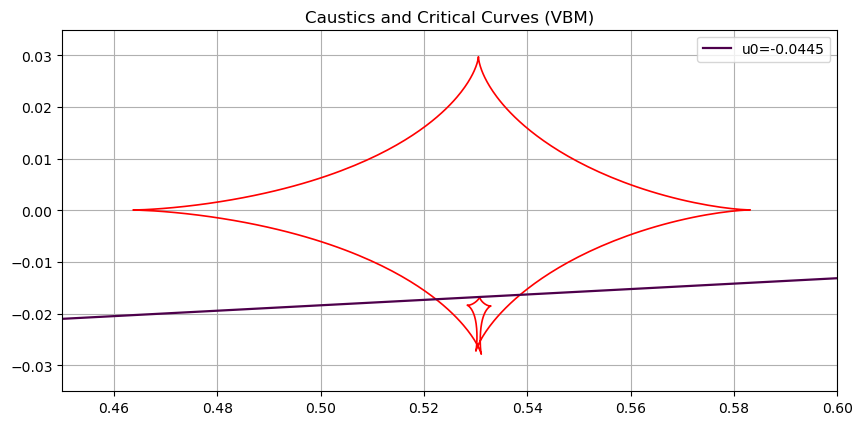

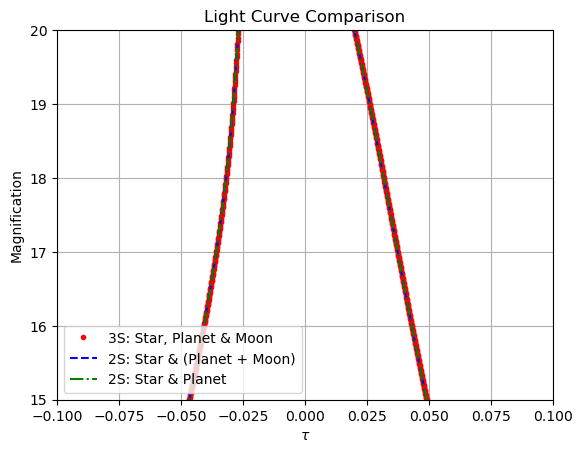

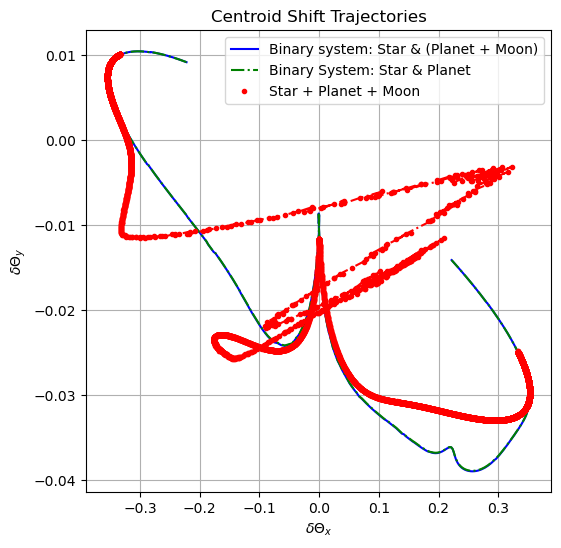

In [5]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[-0.0445] #paper

t0 = 0
tE = 20
rho = 0.0018
rs = rho

secnum = 45
basenum = 2
num_points = 10000

#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 357, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 357, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 357,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 357, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 357,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

triple_model.plot_caustics_and_critical(show=False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

#light curve
plt.plot(triple_model_tau, triple_model_mag, '.', label = "3S: Star, Planet & Moon", color = 'red')
plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlim(-.1, .1)
plt.ylim(15, 20)

plt.xlabel(r"$\tau$")
plt.ylabel("Magnification")
plt.title("Light Curve Comparison")
plt.grid(True)
plt.legend(loc = 'lower left')
plt.show()

#setting up centroid
two_system = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system = triple_model.systems[0]

delta_x_two = two_system['cent_x_hr'] - two_system['x_src_hr']
delta_y_two = two_system['cent_y_hr'] - two_system['y_src_hr']

delta_x_two_B = binary_system['cent_x_hr'] - binary_system['x_src_hr']
delta_y_two_B = binary_system['cent_y_hr'] - binary_system['y_src_hr']

delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

#centroid
plt.figure(figsize=(6,6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [7]:
# --- ALIGN PHOTOMETRY TO THE HIGH-RES GRID ---
tau_hr = triple_model_tau                 # len ~ 50_000
mag3_hr = triple_model_mag                # triple, already on high-res

# Recompute binaries on high-res (fast; doesn't rerun triple)
A_bin_hr = double_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q4), u0_list[0], 357, np.log(rho), np.log(tE), t0],
    triple_model.highres_t
)[0]
B_bin_hr = binary_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q2), u0_list[0], 357, np.log(rho), np.log(tE), t0],
    triple_model.highres_t
)[0]

# sanity
assert len(tau_hr) == len(mag3_hr) == len(A_bin_hr) == len(B_bin_hr)

# ---- SAVE PHOTOMETRY (tau + 3 light curves) ----
photometry = np.column_stack([tau_hr, mag3_hr, A_bin_hr, B_bin_hr])
header_phot = "tau,mag_triple,mag_bin_q4,mag_bin_q2"
np.savez_compressed("photometry_m1.npz", data=photometry)
np.savetxt("photometry_m1.csv", photometry, delimiter=",", header=header_phot,
           comments="", fmt="%.10e")

In [8]:
import numpy as np

# --- Build named arrays (keep each series with its own tau) ---
tau_hr = triple_model.highres_tau                # photometry grid (and your *_hr binaries)
tau_ast3 = getattr(triple_model, "tau", None)    # triple astrometry grid (base)
if tau_ast3 is None or len(tau_ast3) != len(delta_x_three):
    # if triple_model.tau isn't available, just make a dummy index for readability
    tau_ast3 = np.arange(len(delta_x_three), dtype=float)

# binaries' astrometry tau; should match high-res since you used *_hr
tau_ast2A = getattr(double_model, "highres_tau",
                    getattr(double_model, "tau", np.arange(len(delta_x_two), dtype=float)))
tau_ast2B = getattr(binary_model, "highres_tau",
                    getattr(binary_model, "tau", np.arange(len(delta_x_two_B), dtype=float)))

cols = {
    # Photometry (high-res)
    "tau_triple": tau_hr,
    "mag_triple": triple_model_mag,
    "tau_bin_q4": tau_hr,
    "mag_bin_q4": A_bin,
    "tau_bin_q2": tau_hr,
    "mag_bin_q2": B_bin,

    # Astrometry (each with its own tau)
    "tau_ast_triple": tau_ast3,
    "dx_three": delta_x_three,
    "dy_three": delta_y_three,

    "tau_ast_twoA": tau_ast2A,
    "dx_twoA": delta_x_two,
    "dy_twoA": delta_y_two,

    "tau_ast_twoB": tau_ast2B,
    "dx_twoB": delta_x_two_B,
    "dy_twoB": delta_y_two_B,
}

# ---- Save #1: NPZ with separate named arrays (no padding) ----
np.savez_compressed("mass_m1.npz", **cols)

# ---- Save #2: CSV with per-series tau columns (pad to max length with NaN) ----
names = list(cols.keys())
maxlen = max(len(v) for v in cols.values())
M = np.full((maxlen, len(names)), np.nan)
for j, name in enumerate(names):
    arr = np.asarray(cols[name])
    M[:len(arr), j] = arr

np.savetxt(
    "massm1.csv",
    M,
    delimiter=",",
    header=",".join(names),
    comments="",
    fmt="%.10e",
)

print("Saved mixed_lengths.npz and mixed_lengths.csv")

Saved mixed_lengths.npz and mixed_lengths.csv
